In [ ]:
library(tidyverse)
library(knitr)
library(scales)
library(patchwork)
library(corrplot)
library(broom)
library(AER)
library(modelr)
library(ISLR)
library(dplyr)
install.packages("arm")
library(arm)

also installing the dependency ‘coda’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:patchwork’:

    area


The following object is masked from ‘package:dplyr’:

    select


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: lme4


arm (Version 1.15-3, built: 2026-4-15)


Working directory is /home/jovyan/work/stat301-project



Attaching package: ‘arm’


The following object is masked from ‘package:car’:

    logit


The following object is masked from ‘package:corrplot’:

    corrplot


The following object is masked from ‘package:scales’:

    rescale




In [2]:
data <- read_csv("Toronto_apartment_rentals_2018.csv")

Rows: 1124 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Address, Price
dbl (5): Bedroom, Bathroom, Den, Lat, Long

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
data <- data %>%
  # Removing duplicate rows
  distinct() %>%
  # Removing unnecessary columns
  select(-c(Address, Lat, Long)) %>%
  # Making the column names lowercase
  rename_with(tolower) %>%
  # Converting price to a number
  mutate(price = parse_number(price)) %>%
  # Removing outliers
  filter(!price %in% c(65, 99, 99, 36900, 535000)) %>%
mutate(high_price = if_else(price > mean(price), 1, 0))

In [4]:
data <- data %>%
  mutate(high_price = if_else(price > mean(price), 1, 0))

In [28]:
nrow(data)
head(data)

[1] 811

bedroom,bathroom,den,price,high_price
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,2,0,2450,1
1,1,1,2150,0
1,1,0,1950,0
2,2,0,2900,1
1,1,0,1800,0
1,1,0,1729,0


In [56]:
linear_add <- lm(price ~ bedroom + bathroom, data = data)

linear_add_results <- 
   tidy(linear_add, conf.int = TRUE, conf.level = 0.95) %>%
   mutate_if(is.numeric, round, 2)
linear_add_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1026.44,74.50,13.78,0,880.20,1172.68
bedroom,206.60,54.54,3.79,0,99.53,313.66
bathroom,707.66,70.73,10.01,0,568.83,846.49


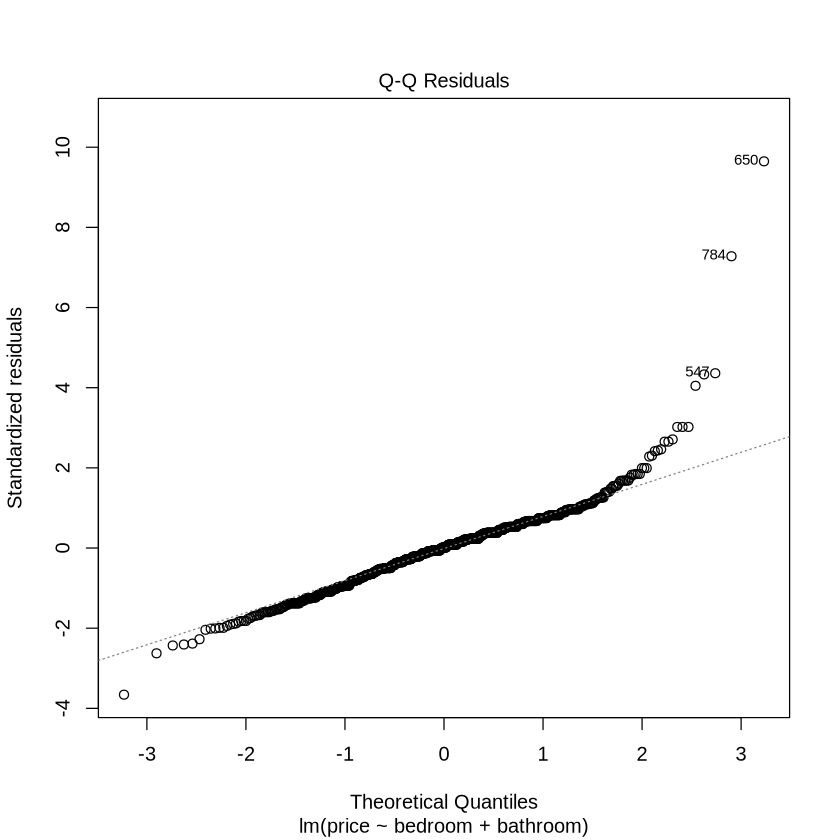

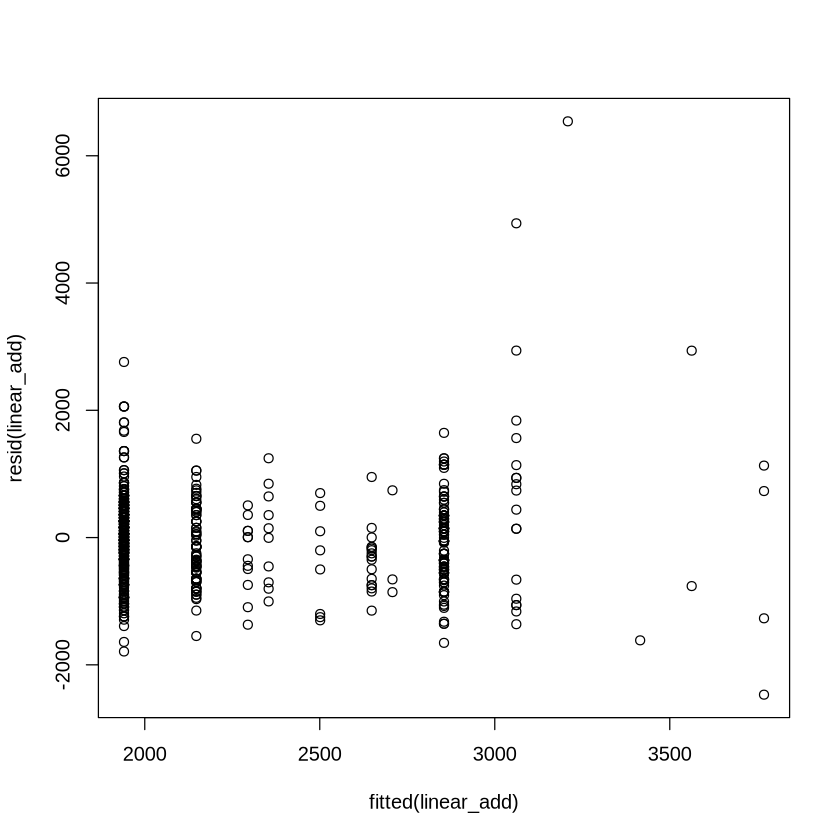

In [57]:
plot(linear_add, 2)
plot(fitted(linear_add), resid(linear_add))

In [51]:
linear_mult <- lm(price ~ bedroom * bathroom, data = data)

linear_mult_results <- 
   tidy(linear_mult, conf.int = TRUE, conf.level = 0.95) %>%
   mutate_if(is.numeric, round, 2)
linear_mult_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1609.69,238.10,6.76,0.00,1142.32,2077.07
bedroom,-131.33,141.90,-0.93,0.35,-409.86,147.20
bathroom,215.80,203.38,1.06,0.29,-183.42,615.02
bedroom:bathroom,263.75,102.30,2.58,0.01,62.94,464.56


**Not statistically significant. Also you can just tell its wrong, like why is the estimate for bedroom negative come on**

In [21]:
logistic_add <- glm(high_price ~ bedroom + bathroom, data = data)

logistic_add_results <- 
   tidy(logistic_add, conf.int = TRUE, conf.level = 0.95) %>%
   mutate_if(is.numeric, round, 2)
logistic_add_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.04,0.05,-0.85,0.40,-0.14,0.06
bedroom,0.05,0.04,1.30,0.19,-0.02,0.12
bathroom,0.36,0.05,7.44,0.00,0.27,0.46


In [22]:
logistic_mult <- glm(high_price ~ bedroom * bathroom, data = data)

logistic_mult_results <- 
   tidy(logistic_mult, conf.int = TRUE, conf.level = 0.95) %>%
   mutate_if(is.numeric, round, 2)
logistic_mult_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.29,0.16,-1.77,0.08,-0.61,0.03
bedroom,0.19,0.10,1.96,0.05,0.00,0.38
bathroom,0.57,0.14,4.07,0.00,0.29,0.84
bedroom:bathroom,-0.11,0.07,-1.58,0.11,-0.25,0.03


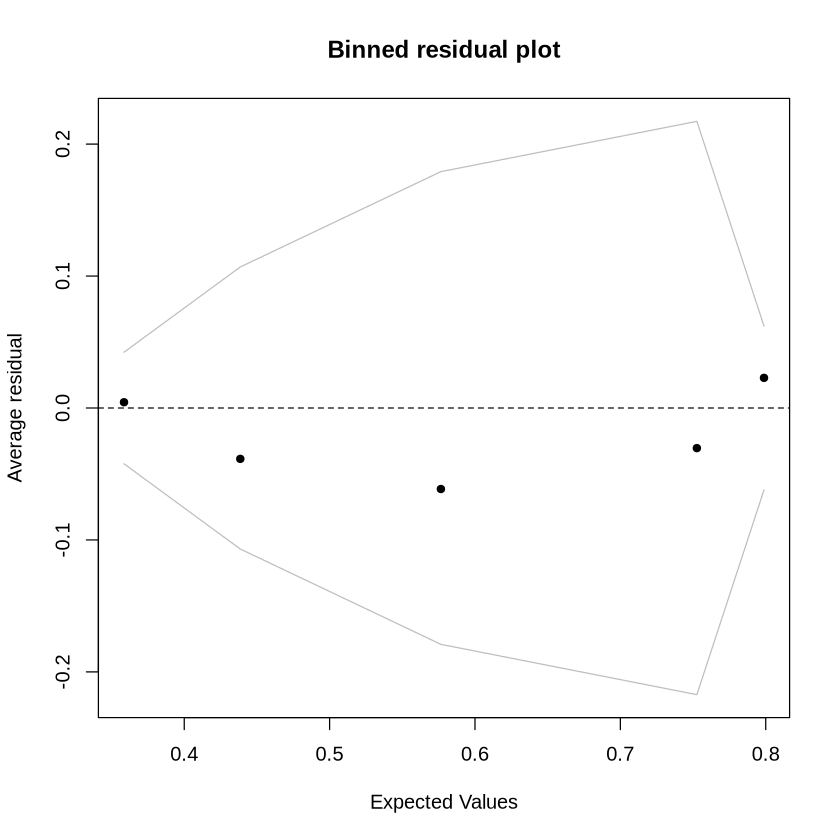

In [26]:
binnedplot(fitted(logistic_mult), resid(logistic_mult))

In [12]:
data <-
    data %>% 
    add_predictions(linear, var = 'linear_predictions')

linear_plot <- 
    data %>%
    ggplot(aes(x = bedroom, y = price, color = bathroom)) +
    geom_point() +
    geom_line(aes(y = linear_predictions), linewidth = 1) +
    labs(title = 'Reading score vs income by grade range without interactions',
         x = 'Number of bedrooms',
         y = 'Price') +
    theme(text = element_text(size = 16.5),
          plot.title = element_text(face = "bold"),
          axis.title = element_text(face = "bold"),
          legend.title = element_text(face = "bold")) +
    labs(color = "Number of bathrooms")

# your code here
# fail() # No Answer - remove if you provide an answer

# linear_plot

ERROR: Error: object 'linear' not found
